<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/hw09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CH2 Forecasting

In [2]:
import pandas as pd
carsales=pd.read_csv('carsales.csv')

In [3]:
print(carsales.head())

     Month  Monthly car sales in Quebec 1960-1968
0  1960-01                                 6550.0
1  1960-02                                 8728.0
2  1960-03                                12026.0
3  1960-04                                14395.0
4  1960-05                                14587.0


In [4]:
carsales.columns= ['month','sales']
print(carsales.tail())

                                     month    sales
104                                1968-09  14385.0
105                                1968-10  21342.0
106                                1968-11  17180.0
107                                1968-12  14577.0
108  Monthly car sales in Quebec 1960-1968      NaN


In [24]:
carsales=carsales.loc[0:107,:].copy()
carsales['period']=list(range(108))
print(carsales.tail())

       month    sales  period  quadratic    cubic  sin_period    cos_period  \
103  1968-08  16722.0     103      10609  1092727   -0.500000 -8.660254e-01   
104  1968-09  14385.0     104      10816  1124864   -0.866025 -5.000000e-01   
105  1968-10  21342.0     105      11025  1157625   -1.000000  3.185939e-15   
106  1968-11  17180.0     106      11236  1191016   -0.866025  5.000000e-01   
107  1968-12  14577.0     107      11449  1225043   -0.500000  8.660254e-01   

     squareroot   exponent15       log  
103   10.148892  1045.335831  4.644391  
104   10.198039  1060.596059  4.653960  
105   10.246951  1075.929830  4.663439  
106   10.295630  1091.336795  4.672829  
107   10.344080  1106.816606  4.682131  


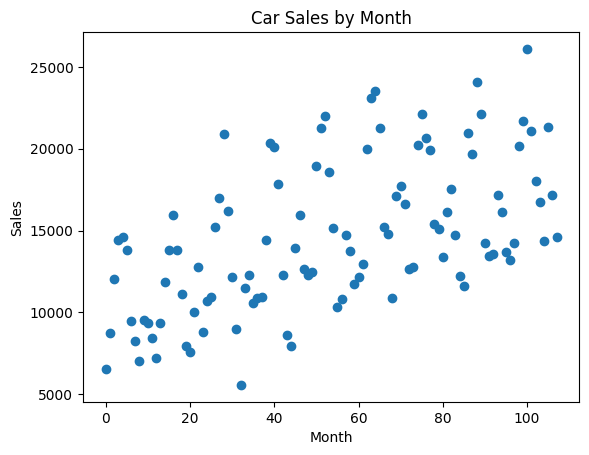

In [6]:
from matplotlib import pyplot as plt

plt.scatter(carsales['period'],carsales['sales'])
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [7]:
x = carsales['period'].values.reshape(-1,1)
y = carsales['sales'].values.reshape(-1,1)

print(x)
print(y)

[[  0]
 [  1]
 [  2]
 [  3]
 [  4]
 [  5]
 [  6]
 [  7]
 [  8]
 [  9]
 [ 10]
 [ 11]
 [ 12]
 [ 13]
 [ 14]
 [ 15]
 [ 16]
 [ 17]
 [ 18]
 [ 19]
 [ 20]
 [ 21]
 [ 22]
 [ 23]
 [ 24]
 [ 25]
 [ 26]
 [ 27]
 [ 28]
 [ 29]
 [ 30]
 [ 31]
 [ 32]
 [ 33]
 [ 34]
 [ 35]
 [ 36]
 [ 37]
 [ 38]
 [ 39]
 [ 40]
 [ 41]
 [ 42]
 [ 43]
 [ 44]
 [ 45]
 [ 46]
 [ 47]
 [ 48]
 [ 49]
 [ 50]
 [ 51]
 [ 52]
 [ 53]
 [ 54]
 [ 55]
 [ 56]
 [ 57]
 [ 58]
 [ 59]
 [ 60]
 [ 61]
 [ 62]
 [ 63]
 [ 64]
 [ 65]
 [ 66]
 [ 67]
 [ 68]
 [ 69]
 [ 70]
 [ 71]
 [ 72]
 [ 73]
 [ 74]
 [ 75]
 [ 76]
 [ 77]
 [ 78]
 [ 79]
 [ 80]
 [ 81]
 [ 82]
 [ 83]
 [ 84]
 [ 85]
 [ 86]
 [ 87]
 [ 88]
 [ 89]
 [ 90]
 [ 91]
 [ 92]
 [ 93]
 [ 94]
 [ 95]
 [ 96]
 [ 97]
 [ 98]
 [ 99]
 [100]
 [101]
 [102]
 [103]
 [104]
 [105]
 [106]
 [107]]
[[ 6550.]
 [ 8728.]
 [12026.]
 [14395.]
 [14587.]
 [13791.]
 [ 9498.]
 [ 8251.]
 [ 7049.]
 [ 9545.]
 [ 9364.]
 [ 8456.]
 [ 7237.]
 [ 9374.]
 [11837.]
 [13784.]
 [15926.]
 [13821.]
 [11143.]
 [ 7975.]
 [ 7610.]
 [10015.]
 [12759.]
 [ 8816.]
 [1

In [25]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x, y)
print(regressor.coef_)
print(regressor.intercept_)

[[81.20250174]]
[10250.77726809]


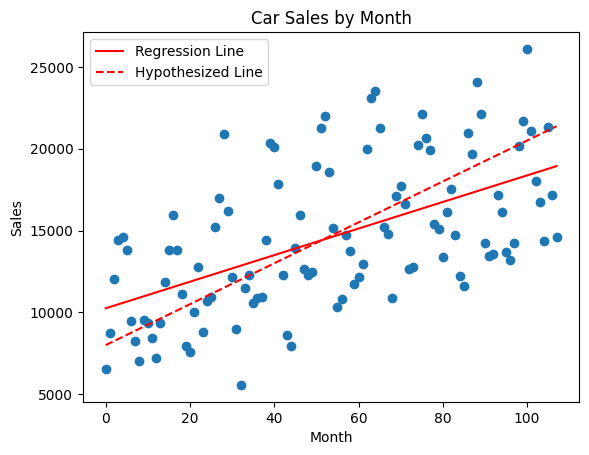

In [9]:
plt.scatter(carsales['period'],carsales['sales'])
plt.plot(carsales['period'],[81.2 * i + 10250.8 for i in \
carsales['period']],'r-',label='Regression Line')
plt.plot(carsales['period'],[125 * i + 8000 for i in
carsales['period']],'r--',label='Hypothesized Line')
plt.legend(loc="upper left")
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [10]:
saleslist=carsales['sales'].tolist()
regressionline=[81.2 * i + 10250.8 for i in carsales['period']]
hypothesizedline=[125 * i + 8000 for i in carsales['period']]
error1=[(x-y) for x, y in zip(regressionline,saleslist)]
error2=[(x-y) for x, y in zip(hypothesizedline,saleslist)]

print(error1)
print(error2)

[3700.7999999999993, 1604.0, -1612.800000000001, -3900.6000000000004, -4011.4000000000015, -3134.2000000000007, 1240.0, 2568.199999999999, 3851.3999999999996, 1436.5999999999985, 1698.7999999999993, 2688.0, 3988.199999999999, 1932.3999999999996, -449.40000000000146, -2315.2000000000007, -4376.0, -2189.800000000001, 569.3999999999996, 3818.5999999999985, 4264.799999999999, 1941.0, -721.8000000000011, 3302.3999999999996, 1522.5999999999985, 1333.7999999999993, -2838.0, -4566.800000000001, -8375.6, -3599.4000000000015, 543.7999999999993, 3771.0, 7281.199999999999, 1456.3999999999996, 755.5999999999985, 2509.7999999999993, 2312.0, 2290.199999999999, -1068.6000000000004, -6961.4000000000015, -6629.200000000001, -4236.0, 1393.199999999999, 5100.4, 5861.5999999999985, -27.200000000000728, -1950.0, 1439.199999999999, 1881.3999999999996, 1759.5999999999985, -4633.200000000001, -6867.0, -7541.799999999999, -4026.6000000000004, -539.4000000000015, 4410.799999999999, 4006.0, 127.20000000000073, 12

In [11]:
import numpy as np
error1abs=[abs(value) for value in error1]
error2abs=[abs(value) for value in error2]
print(np.mean(error1abs))
print(np.mean(error2abs))

3154.3592592592595
3239.777777777778


In [12]:
error1squared=[(value)**2 for value in error1]
error2squared=[(value)**2 for value in error2]
print(np.sqrt(np.mean(error1squared)))
print(np.sqrt(np.mean(error2squared)))

3725.491219512759
3968.900519455399


In [13]:
def get_mae(line,actual):
 error=[(x-y) for x,y in zip(line,actual)]
 errorabs=[abs(value) for value in error]
 mae=np.mean(errorabs)
 return(mae)

def get_rmse(line,actual):
 error=[(x-y) for x,y in zip(line,actual)]
 errorsquared=[(value)**2 for value in error]
 rmse=np.sqrt(np.mean(errorsquared))
 return(rmse)

In [14]:
x_extended = np.append(carsales['period'], np.arange(108, 116))

x_extended=x_extended.reshape(-1,1)
extended_prediction=regressor.predict(x_extended)

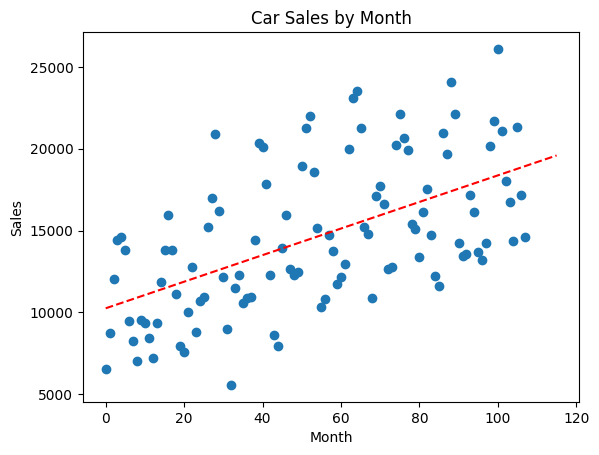

In [15]:
plt.scatter(carsales['period'],carsales['sales'])
plt.plot(x_extended,extended_prediction,'r--')
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

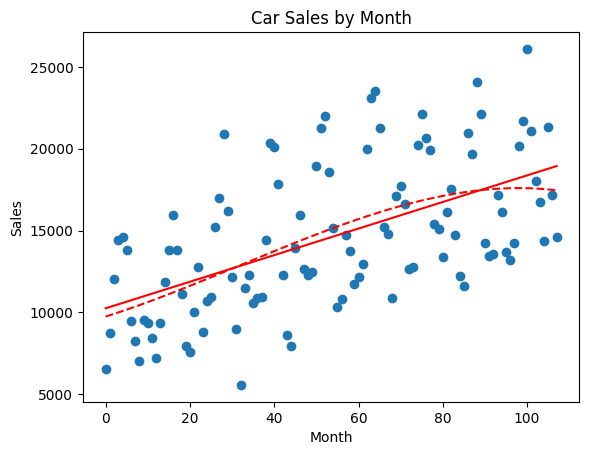

In [16]:
carsales['quadratic']=carsales['period'].apply(lambda x: x**2)
carsales['cubic']=carsales['period'].apply(lambda x: x**3)
x3 = carsales.loc[:,['period','quadratic','cubic']].values.reshape(-1,3)
y = carsales['sales'].values.reshape(-1,1)
regressor_cubic = LinearRegression()
regressor_cubic.fit(x3, y)
plt.scatter(carsales['period'],carsales['sales'])
plt.plot(x,regressor.predict(x),'r-')
plt.plot(x,regressor_cubic.predict(x3),'r--')
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [17]:
print(regressor_cubic.coef_)
print(regressor_cubic.intercept_)

[[ 8.13410634e+01  7.90279561e-01 -8.19451188e-03]]
[9746.41276055]


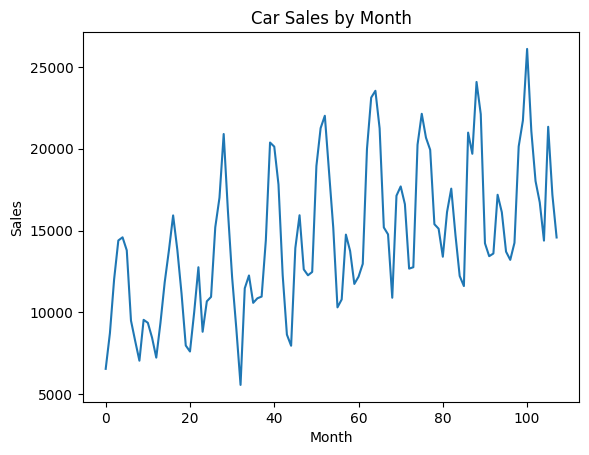

In [18]:
plt.plot(carsales['period'],carsales['sales'])
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

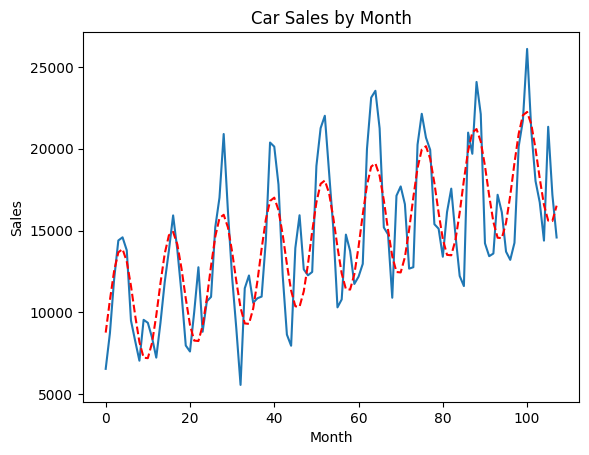

In [19]:
import math
carsales['sin_period']=carsales['period'].apply(lambda x: math.sin(x*2*math.pi/12))
carsales['cos_period']=carsales['period'].apply(lambda x: math.cos(x*2*math.pi/12))
x_trig = carsales.loc[:,['period','sin_period','cos_period']].values.reshape(-1,3)
y = carsales['sales'].values.reshape(-1,1)
regressor_trig = LinearRegression()
regressor_trig.fit(x_trig, y)
plt.plot(carsales['period'],carsales['sales'])
plt.plot(x,regressor_trig.predict(x_trig),'r--')
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [20]:
trig_line=regressor_trig.predict(x_trig)[:, 0]
print(get_rmse(trig_line,saleslist))

2680.5520744410464


In [21]:
carsales['squareroot']=carsales['period'].apply(lambda x: x**0.5)
carsales['exponent15']=carsales['period'].apply(lambda x: x**1.5)
carsales['log']=carsales['period'].apply(lambda x: math.log(x+1))
x_complex = carsales.loc[:,['period','log','sin_period','cos_period', \
'squareroot','exponent15','log','quadratic', 'cubic']].values.reshape(-1,9)
y = carsales['sales'].values.reshape(-1,1)
regressor_complex = LinearRegression()
regressor_complex.fit(x_complex,y)
complex_line=[prediction for sublist in regressor_complex.predict(x_complex) \
for prediction in sublist]
print(get_rmse(complex_line,saleslist))

2610.3938122978843


In [22]:
x_complex_train = carsales.loc[0:80,['period','log','sin_period','cos_period','squareroot', \
'exponent15','log','quadratic','cubic']].values.reshape(-1,9)
y_train = carsales.loc[0:80,'sales'].values.reshape(-1,1)
x_complex_test = carsales.loc[81:107,['period','log','sin_period','cos_period','squareroot', \
'exponent15','log','quadratic','cubic']].values.reshape(-1,9)
y_test = carsales.loc[81:107,'sales'].values.reshape(-1,1)
regressor_complex.fit(x_complex_train, y_train)

LinearRegression()

In [23]:
x_train = carsales.loc[0:80,['period']].values.reshape(-1,1)
x_test = carsales.loc[81:107,['period']].values.reshape(-1,1)
x_trig_train = carsales.loc[0:80,['period','sin_period','cos_period']].values.reshape(-1,3)
x_trig_test = carsales.loc[81:107,['period','sin_period','cos_period']].values.reshape(-1,3)
regressor.fit(x_train, y_train)
regressor_trig.fit(x_trig_train, y_train)
complex_test_predictions=[prediction for sublist in \
 regressor_complex.predict(x_complex_test) for prediction in sublist]
test_predictions=[prediction for sublist in regressor.predict(x_test) for \
 prediction in sublist]
trig_test_predictions=[prediction for sublist in \
 regressor_trig.predict(x_trig_test) for prediction in sublist]
print(get_rmse(test_predictions,saleslist[81:107]))
print(get_rmse(trig_test_predictions,saleslist[81:107]))
print(get_rmse(complex_test_predictions,saleslist[81:107]))

4115.614379193304
3461.0823292599357
6006.013164062921


Summary/Storyline:
  The goal of this chapter is to apply forecasting, or regression, tools to basic business data with the intent of making smarter, better-informed business decisions. This chapter covers linear regression (both single and multi-variable regressions) and later dives into some different types, such as trig regressions.

  The chapter begins with some minor data cleaning, sorting out the column names,removing unnecessary rows, and creating new variables. Then, we move on to basic matplotlib visualizations so we can observe general trends in the data. Next, we import our library for linear regression and enact our first one to get the regression coefficient, intercept, and a graph with the regression line plotted. We also add on a hypothesized line onto the graph with the regression.

  We then move on to error calculations. It takes a couple steps, but eventually we come up with the mean average error for both our hypothesized and regression lines. Next, we turn the MAE numbers into the root mean square error which gives us an indication of how accurate, and therefore useful, our line is.

  We now move onto the actual forecasting. We extend our regression line to predict car sale values for future periods and then plot it. The chapter next experiments with multi-variable regression by incorporating squared and cubed values of our exisisting one variable. The cubic regression line also fits the data.
  
  After turning the data into a line plot rather than a scatter plot, a trigonometric relationship is shown. We create a trig regression which fits the data well. This is supported by the fact that it has a lower RMSE than the earlier linear regression.